In [1]:
%pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.9 kB/s eta 0:00:00a 0:00:04

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
"""
marvel_stats.py — size/density/centralities + optional plots for a GraphML network.

Usage (stats only):
  python marvel_stats.py "C:\\path\\to\\marvel-network.graphml" --top 10

Add plots (PNG files):
  python marvel_stats.py "C:\\path\\to\\marvel-network.graphml" --plot --k 20 --label-top 10 --prefix marvel_vis

Requirements:
  pip install networkx matplotlib
"""

'\nmarvel_stats.py — size/density/centralities + optional plots for a GraphML network.\n\nUsage (stats only):\n  python marvel_stats.py "C:\\path\\to\\marvel-network.graphml" --top 10\n\nAdd plots (PNG files):\n  python marvel_stats.py "C:\\path\\to\\marvel-network.graphml" --plot --k 20 --label-top 10 --prefix marvel_vis\n\nRequirements:\n  pip install networkx matplotlib\n'

In [4]:
def top_n(d, k=10):
    return sorted(d.items(), key=lambda x: (-x[1], x[0]))[:k]

In [6]:
graphml_path = Path("/Users/danielcanhedo/CIS400_DataMining/Social_Media_Data_Mining_Project/marvel-network.graphml")

if not graphml_path.exists():
    print(f"ERROR: GraphML not found at {graphml_path.resolve()}")
else:
    print(f"Loading network from: {graphml_path.resolve()}")

Loading network from: /Users/danielcanhedo/CIS400_DataMining/Social_Media_Data_Mining_Project/marvel-network.graphml


In [7]:
Graw = nx.read_graphml(graphml_path)
G = nx.Graph()
G.add_nodes_from(Graw.nodes(data=True))
for u, v, data in Graw.edges(data=True):
    if u != v:
        G.add_edge(u, v, **data)

print("Network loaded successfully!")

print("=== Basic Statistics ===")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")
print(f"Connected: {nx.is_connected(G)}")

Network loaded successfully!
=== Basic Statistics ===
Nodes: 327
Edges: 9891
Density: 0.185569
Connected: True


In [8]:
# Degree (interactions)
degree = dict(G.degree())
top_degree = top_n(degree, 10)

print("=== Top by Degree (most interactions) ===")
for i, (n, val) in enumerate(top_degree, 1):
    print(f"{i}. {n}: {val}")

=== Top by Degree (most interactions) ===
1. Captain America: 258
2. Wolverine / Logan: 220
3. Spider-man / Peter Parker: 218
4. Thing / Benjamin J. Gr: 214
5. Vision: 213
6. Beast / Henry &hank& P: 205
7. Thor / Dr. Donald Blak: 205
8. Iron Man / Tony Stark: 203
9. Mr. Fantastic / Reed R: 198
10. Cyclops / Scott Summer: 197


In [10]:
# Degree Centrality
print("=== Centralities (popularity/influence) ===")
deg_cent = nx.degree_centrality(G)
print("\nTop Degree Centrality:")
for i, (n, val) in enumerate(top_n(deg_cent, 10), 1):
    print(f"{i}. {n}: {val:.6f}")

=== Centralities (popularity/influence) ===

Top Degree Centrality:
1. Captain America: 0.791411
2. Wolverine / Logan: 0.674847
3. Spider-man / Peter Parker: 0.668712
4. Thing / Benjamin J. Gr: 0.656442
5. Vision: 0.653374
6. Beast / Henry &hank& P: 0.628834
7. Thor / Dr. Donald Blak: 0.628834
8. Iron Man / Tony Stark: 0.622699
9. Mr. Fantastic / Reed R: 0.607362
10. Cyclops / Scott Summer: 0.604294


In [11]:
# Closeness Centrality
close = nx.closeness_centrality(G)
print("Top Closeness Centrality:")
for i, (n, val) in enumerate(top_n(close, 10), 1):
    print(f"{i}. {n}: {val:.6f}")

Top Closeness Centrality:
1. Captain America: 0.827411
2. Wolverine / Logan: 0.754630
3. Spider-man / Peter Parker: 0.751152
4. Thing / Benjamin J. Gr: 0.744292
5. Vision: 0.742597
6. Beast / Henry &hank& P: 0.729306
7. Thor / Dr. Donald Blak: 0.729306
8. Iron Man / Tony Stark: 0.726058
9. Mr. Fantastic / Reed R: 0.718062
10. Cyclops / Scott Summer: 0.716484


In [12]:
# Betweenness Centrality
bet = nx.betweenness_centrality(G, normalized=True)
print("Top Betweenness Centrality:")
for i, (n, val) in enumerate(top_n(bet, 10), 1):
    print(f"{i}. {n}: {val:.6f}")

Top Betweenness Centrality:
1. Captain America: 0.067124
2. Spider-man / Peter Parker: 0.061809
3. Wolverine / Logan: 0.035487
4. Beast / Henry &hank& P: 0.031203
5. Thor / Dr. Donald Blak: 0.028648
6. Vision: 0.028624
7. Thing / Benjamin J. Gr: 0.025037
8. Iron Man / Tony Stark: 0.024893
9. Cyclops / Scott Summer: 0.022348
10. Mr. Fantastic / Reed R: 0.021072


In [13]:
# PageRank
pr = nx.pagerank(G, alpha=0.85)
print("Top PageRank:")
for i, (n, val) in enumerate(top_n(pr, 10), 1):
    print(f"{i}. {n}: {val:.6f}")

Top PageRank:
1. Captain America: 0.022782
2. Spider-man / Peter Parker: 0.018200
3. Thor / Dr. Donald Blak: 0.016505
4. Iron Man / Tony Stark: 0.015339
5. Thing / Benjamin J. Gr: 0.015035
6. Wolverine / Logan: 0.014449
7. Vision: 0.014321
8. Human Torch / Johnny S: 0.014203
9. Scarlet Witch / Wanda: 0.014103
10. Mr. Fantastic / Reed R: 0.013489


In [14]:
# Eigenvector Centrality
try:
    eig = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
    print("Top Eigenvector Centrality:")
    for i, (n, val) in enumerate(top_n(eig, 10), 1):
        print(f"{i}. {n}: {val:.6f}")
except nx.NetworkXException as e:
    print(f"[Eigenvector centrality skipped: {e}]")

Top Eigenvector Centrality:
1. Captain America: 0.139418
2. Wolverine / Logan: 0.131218
3. Thing / Benjamin J. Gr: 0.129755
4. Vision: 0.127247
5. Beast / Henry &hank& P: 0.126039
6. Spider-man / Peter Parker: 0.123751
7. Human Torch / Johnny S: 0.123180
8. Invisible Woman / Sue: 0.123150
9. Cyclops / Scott Summer: 0.123089
10. Scarlet Witch / Wanda: 0.122284


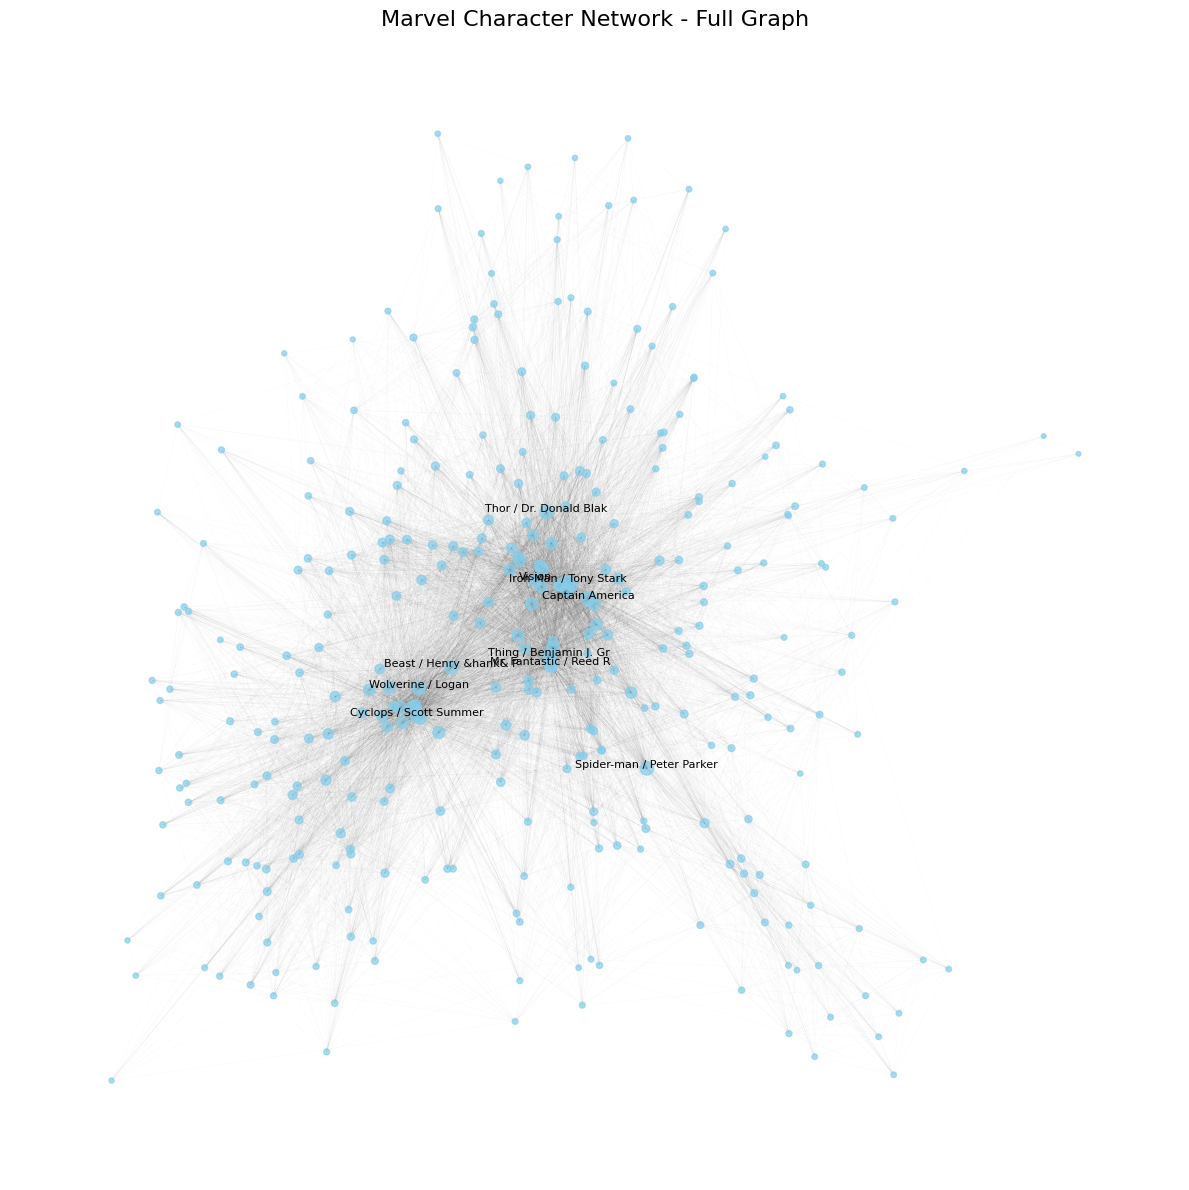

Saved: marvel_network_full.png


In [15]:
# Create layout
pos = nx.spring_layout(G, seed=42)

# Full network visualization
sizes = [8 + 0.4 * degree[n] for n in G.nodes()]
plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.03, width=0.3)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color='skyblue', alpha=0.7)

# Label top 10 nodes by degree
top = sorted(degree.items(), key=lambda x: (-x[1], x[0]))[:10]
for n, _ in top:
    x, y = pos[n]
    plt.text(x, y, str(n), fontsize=8, ha='center')

plt.axis("off")
plt.title("Marvel Character Network - Full Graph", fontsize=16)
plt.tight_layout()
plt.savefig("marvel_network_full.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: marvel_network_full.png")

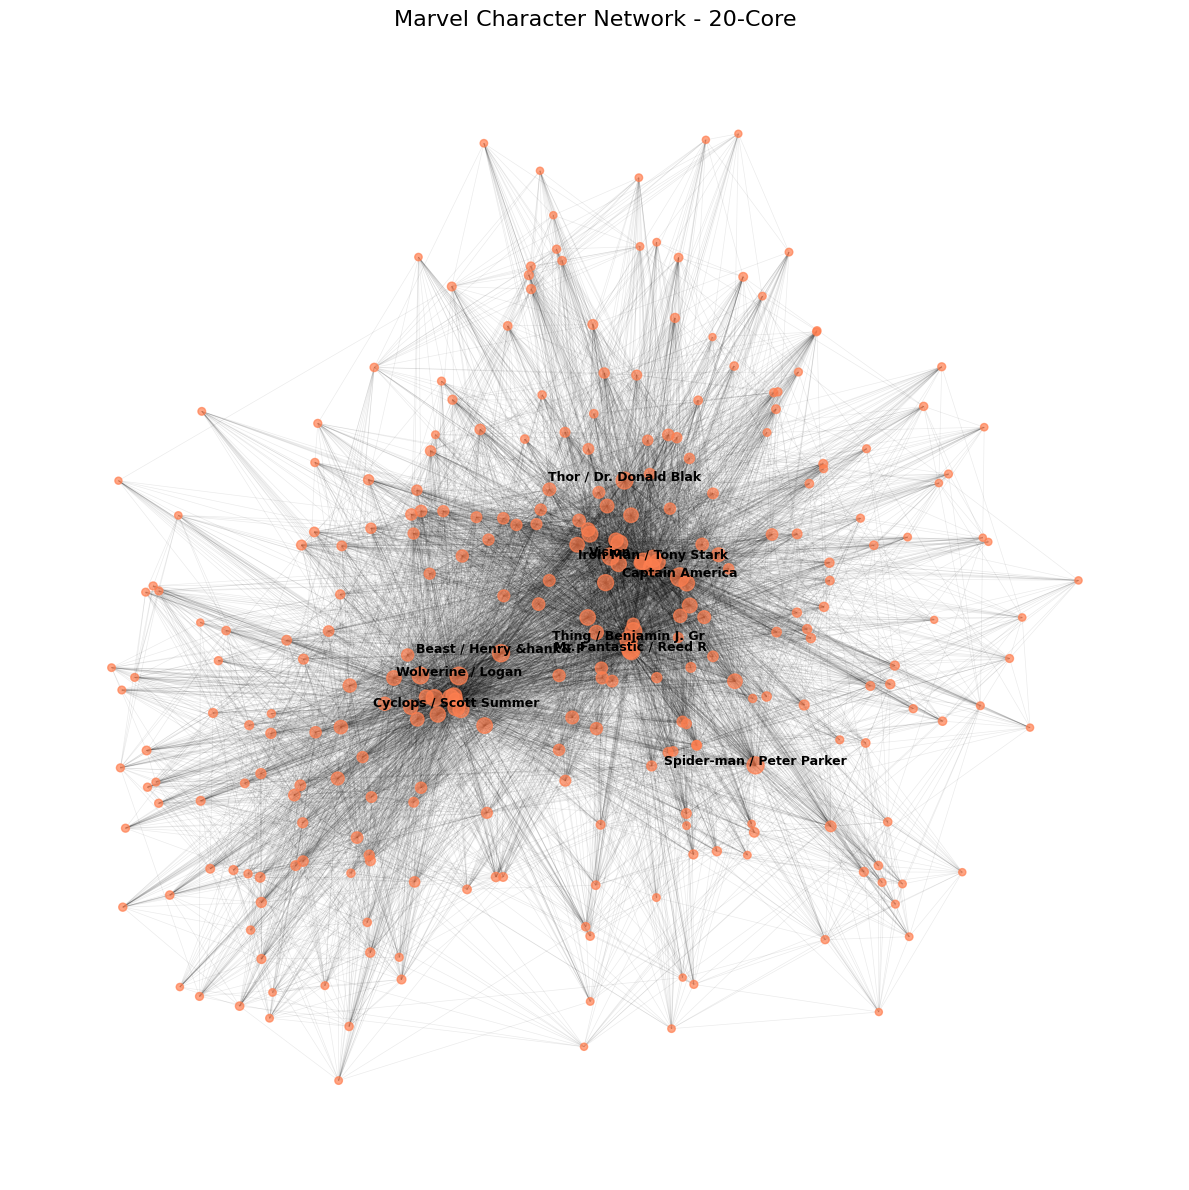

Saved: marvel_network_kcore20.png


In [16]:
# K-core visualization
k_value = 20
try:
    core = nx.k_core(G, k=k_value)
except nx.NetworkXError:
    kmax = nx.core_number(G)
    k_value = max(kmax.values())
    print(f"[Note] Requested k too high; using max k={k_value}")
    core = nx.k_core(G, k=k_value)

deg_core = dict(core.degree())
sizes_core = [12 + 0.7 * deg_core[n] for n in core.nodes()]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(core, pos, alpha=0.08, width=0.5)
nx.draw_networkx_nodes(core, pos, node_size=sizes_core, node_color='coral', alpha=0.7)

# Label top 10 nodes in k-core
topc = sorted(deg_core.items(), key=lambda x: (-x[1], x[0]))[:10]
for n, _ in topc:
    x, y = pos[n]
    plt.text(x, y, str(n), fontsize=9, ha='center', weight='bold')

plt.axis("off")
plt.title(f"Marvel Character Network - {k_value}-Core", fontsize=16)
plt.tight_layout()
plt.savefig(f"marvel_network_kcore{k_value}.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved: marvel_network_kcore{k_value}.png")